In [61]:
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

df_train = pd.read_csv('../datasets/clean.csv')
df_test = pd.read_csv('../datasets/power_leak.csv')

eps_features = ['total_drain', 'solar_input', 'is_scrubber_on', 'is_engine_on', 'pitch']

X_train = df_train[eps_features]
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

model = IsolationForest(n_estimators=100, contamination=0.01, random_state=42)
model.fit(X_train_scaled)

df_test_filtered = df_test[df_test['timestamp'] > 100].copy()
X_test_scaled = scaler.transform(df_test_filtered[eps_features])

df_test_filtered['scores'] = model.decision_function(X_test_scaled)
df_test_filtered['anomaly_pred'] = model.predict(X_test_scaled)


In [62]:
print(df_test_filtered[['timestamp', 'net_power', 'total_drain', 'solar_input', 'is_scrubber_on', 'is_engine_on']][df_test_filtered['is_anomaly'] == 1].iloc[0])

timestamp           577.000000
net_power          8074.364498
total_drain        2000.000000
solar_input       10074.364498
is_scrubber_on        1.000000
is_engine_on          0.000000
Name: 568, dtype: float64


In [64]:
pd.set_option('display.max_rows', 300)
print(len(df_test_filtered[['timestamp', 'solar_input', 'is_scrubber_on', 'is_engine_on']][df_test_filtered['anomaly_pred'] == -1]))
print(df_test_filtered[['timestamp', 'solar_input', 'scores']][df_test_filtered['anomaly_pred'] == -1].head(300))

419
     timestamp   solar_input    scores
172        181  11199.936928 -0.004383
173        182  11199.937290 -0.002510
175        184  11199.937109 -0.004383
177        186  11199.929692 -0.015351
178        187  11199.918031 -0.016782
179        188  11199.927895 -0.016782
180        189  11199.918605 -0.016782
181        190  11199.905767 -0.016782
182        191  11199.906517 -0.016782
183        192  11199.906366 -0.016782
184        193  11199.890018 -0.016782
185        194  11199.902894 -0.016782
186        195  11199.904107 -0.016782
187        196  11199.917577 -0.016782
188        197  11199.903193 -0.016782
189        198  11199.907558 -0.016782
190        199  11199.912577 -0.016782
191        200  11199.923723 -0.016782
192        201  11199.931920 -0.013449
193        202  11199.928735 -0.016782
194        203  11199.923878 -0.016782
195        204  11199.933789 -0.010604
196        205  11199.923269 -0.016782
197        206  11199.923922 -0.016782
198        207  11199

In [65]:
print("Training Mean")
print(df_train[eps_features].mean())
print("Test Mean")
print(df_test[df_test['timestamp'] < 600][eps_features].mean())

Training Mean
total_drain        2774.414062
solar_input       11199.988933
is_scrubber_on        0.751953
is_engine_on          0.899414
pitch               141.016437
dtype: float64
Test Mean
total_drain        2837.563452
solar_input       11153.745420
is_scrubber_on        0.780034
is_engine_on          0.947547
pitch               141.138336
dtype: float64


In [66]:
print(df_train[eps_features].describe().loc[['mean', 'std', 'min', 'max']])

print("\n")
print(df_test[df_test['timestamp'] < 600][eps_features].describe().loc[['mean', 'std', 'min', 'max']])

print("\n")
print(df_train.groupby(['is_scrubber_on', 'is_engine_on']).size())

print("\n")
print(df_test[df_test['timestamp'] < 600].groupby(['is_scrubber_on', 'is_engine_on']).size())

      total_drain   solar_input  is_scrubber_on  is_engine_on       pitch
mean  2774.414062  11199.988933        0.751953      0.899414  141.016437
std    345.887229      0.011488        0.432090      0.300927    0.078943
min   1500.000000  11199.926700        0.000000      0.000000  140.792709
max   3000.000000  11200.000000        1.000000      1.000000  141.172874


      total_drain   solar_input  is_scrubber_on  is_engine_on       pitch
mean  2837.563452  11153.745420        0.780034      0.947547  141.138336
std    284.950461    229.909557        0.414574      0.223129    0.107641
min   2000.000000   9951.163211        0.000000      0.000000  140.972420
max   3000.000000  11200.000000        1.000000      1.000000  141.393058


is_scrubber_on  is_engine_on
0               0                 6
                1               248
1               0                97
                1               673
dtype: int64


is_scrubber_on  is_engine_on
0               1               130
1  

In [77]:
threshold = -0.03

df_test_filtered['custom_pred'] = [1 if score >= threshold else -1 for score in df_test_filtered['scores']]

print(len(df_test_filtered[['solar_input', 'scores', 'custom_pred']][df_test_filtered['custom_pred'] == -1]))
print(df_test_filtered[['solar_input', 'scores', 'custom_pred']][df_test_filtered['custom_pred'] == -1].head(300))

37
      solar_input    scores  custom_pred
568  10074.364498 -0.040378           -1
569  10068.758475 -0.048251           -1
570  10063.161474 -0.040378           -1
571  10057.567712 -0.038827           -1
572  10051.963522 -0.039885           -1
573  10046.358783 -0.047254           -1
574  10040.748650 -0.049249           -1
575  10035.153999 -0.049249           -1
576  10029.551076 -0.049249           -1
577  10023.959690 -0.046757           -1
578  10018.362073 -0.040378           -1
579  10012.763233 -0.039885           -1
580  10007.168460 -0.038827           -1
581  10001.568434 -0.038827           -1
582   9995.964391 -0.039885           -1
583   9990.370160 -0.038827           -1
584   9984.771311 -0.038827           -1
585   9979.174611 -0.037352           -1
586   9973.574215 -0.037843           -1
587   9967.973983 -0.037843           -1
588   9962.367388 -0.039319           -1
589   9956.768160 -0.038827           -1
590   9951.163211 -0.039392           -1
591   9945.55

Trying a chronological split (train-test split) on the leak data so the model learns what is "healthy" directly from the same context.

In [20]:
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('../datasets/power_leak.csv')
eps_features = ['total_drain', 'solar_input', 'is_scrubber_on', 'is_engine_on', 'pitch']

# healthy data
train_data = df[(df['timestamp'] > 100) & (df['timestamp'] < 400)][eps_features]
test_data = df[df['timestamp'] > 100].copy()

for col in ['solar_input', 'pitch']:
    noise = np.random.normal(0, train_data[col].std() * 5, train_data.shape[0])
    train_data[col] = train_data[col] + noise

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_data)

# train model on healthy data
model = IsolationForest(n_estimators=100, contamination=0.01, random_state=42)
model.fit(X_train_scaled)

# predict the whole simulation
X_test_scaled = scaler.transform(test_data[eps_features])
test_data['scores'] = model.decision_function(X_test_scaled)
test_data['pred'] = model.predict(X_test_scaled)

alert = test_data[test_data['scores'] < 0].iloc[0]['timestamp']
print(f"AI Detection (Score < -0.05): T={alert}")
print(len(test_data[test_data['scores'] < -0.03]))
print((test_data[test_data['scores'] < -0.03]))

AI Detection (Score < -0.05): T=646.0
52
      timestamp       pitch     y_pos  ...  is_anomaly    scores  pred
954         963  141.183122  0.155522  ...           1 -0.031447    -1
955         964  141.185109  0.151461  ...           1 -0.031447    -1
956         965  141.198715  0.160271  ...           1 -0.034762    -1
957         966  141.189696  0.168147  ...           1 -0.031447    -1
958         967  141.180277  0.165148  ...           1 -0.031447    -1
968         977  141.177786  0.161052  ...           1 -0.030413    -1
969         978  141.189333  0.161009  ...           1 -0.031447    -1
970         979  141.206474  0.160921  ...           1 -0.034292    -1
971         980  141.202089  0.153454  ...           1 -0.034292    -1
972         981  141.209340  0.149353  ...           1 -0.032412    -1
973         982  141.227629  0.150330  ...           1 -0.032412    -1
974         983  141.241368  0.155808  ...           1 -0.033421    -1
975         984  141.256425  0.16421

### Leak Detection Time

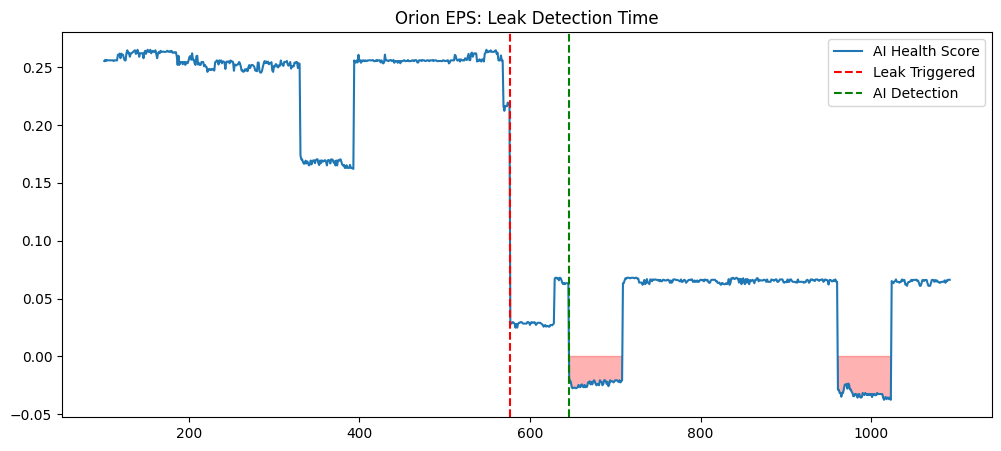

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(test_data['timestamp'], test_data['scores'], label='AI Health Score')
plt.axvline(x=577, color='r', linestyle='--', label='Leak Triggered')
plt.axvline(x=646, color='g', linestyle='--', label='AI Detection')
plt.fill_between(test_data['timestamp'], test_data['scores'], 0, where=(test_data['scores'] < 0), color='red', alpha=0.3)
plt.title("Orion EPS: Leak Detection Time")
plt.legend()
plt.show()